## **Derivable Judgement**

import libraries

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

Load Data

In [2]:
df = pd.read_csv("public_health_dataset.txt")
df.head(1)

,record_id,age_group,age,weight,gender,region,smoking_status,exercise_frequency,bmi,blood_pressure,diabetes,hypertension,cholesterol_level,glucose_level,visit_date
0,5299861a-0d6c-49ca-8ca8-5f0e3ccfcd7f,18-25,23,97,Male,South,Former Smoker,Rarely,23.4,141.6,True,True,159.0,167.2,10/10/2024


**1. Formulate at least two hypotheses from the dataset
Hypothesis 1 (Smoking vs Diabetes)**

**H₀ (Null Hypothesis)**: Smoking has no effect on diabetes prevalence.
**H₁ (Alternative Hypothesis)**: Smoking affects diabetes prevalence.
Hypothesis 2 (Age Group vs Diabetes Rate)

**H₀:** Diabetes rate is the same across all age groups.
**H₁:** Diabetes rate differs across age groups.

**2. Calculate Confidence Intervals (Age & Weight)**

In [3]:
# Age Confidence Interval (95%)
mean_age = df["age"].mean()
std_age = df["age"].std()
n = len(df)
z = 1.96  # for 95% confidence

ci_age = (
    mean_age - z * (std_age / np.sqrt(n)),
    mean_age + z * (std_age / np.sqrt(n))
)

ci_age

(np.float64(41.50118555438675), np.float64(47.930007106163714))

In [4]:
# Weight Confidence Interval (95%)
mean_weight = df["weight"].mean()
std_weight = df["weight"].std()

ci_weight = (
    mean_weight - z * (std_weight / np.sqrt(n)),
    mean_weight + z * (std_weight / np.sqrt(n))
)

ci_weight

(np.float64(78.28889926793993), np.float64(81.71110073206007))

**3. Find Critical Value and p-value**

For α = 0.05:


*   Critical z-value = ±1.96
*   If p-value < 0.05, reject H₀




**4. Perform z-test / t-test (Mean Comparison)**

Example: Mean Age of Diabetic vs Non-Diabetic Individuals

In [5]:
diabetic_age = df[df["diabetes"] == True]["age"]
nondiabetic_age = df[df["diabetes"] == False]["age"]

t_stat, p_value = stats.ttest_ind(diabetic_age, nondiabetic_age)

t_stat, p_value

(np.float64(3.0386985762446863), np.float64(0.00299244111012777))

**Interpretation**

*   If p-value < 0.05 → Reject H₀
*   If p-value ≥ 0.05 → Accept H₀



**5. Chi-Square Test (Smoking Status vs Diabetes)**

In [6]:
contingency_table = pd.crosstab(df["smoking_status"], df["diabetes"])
contingency_table

diabetes,False,True
smoking_status,,
Former Smoker,12,12
Non-Smoker,40,13
Smoker,13,18


In [7]:
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

chi2, p

(np.float64(10.516052815816437), np.float64(0.005205568255698757))

<Figure size 640x480 with 0 Axes>

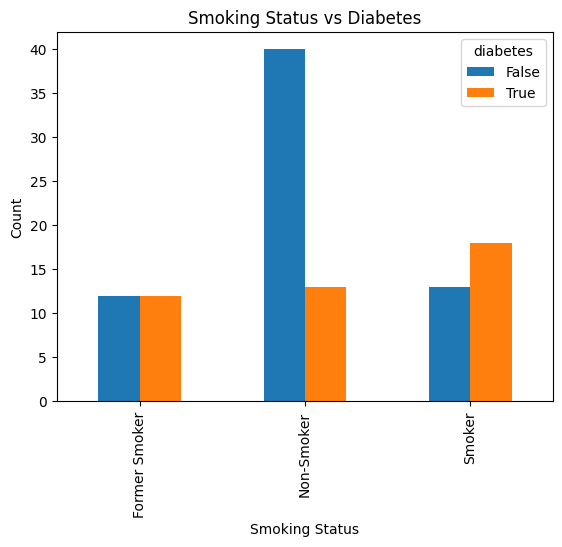

In [8]:
plt.figure()

smoking_diabetes = pd.crosstab(df["smoking_status"], df["diabetes"])
smoking_diabetes.plot(kind="bar")

plt.title("Smoking Status vs Diabetes")
plt.xlabel("Smoking Status")
plt.ylabel("Count")

plt.show()

**Interpretation**
*   p < 0.05 → Smoking and diabetes are associated
*   p ≥ 0.05 → No significant association



**6. ANOVA Test (Age Group vs Diabetes Rate)**

<Figure size 640x480 with 0 Axes>

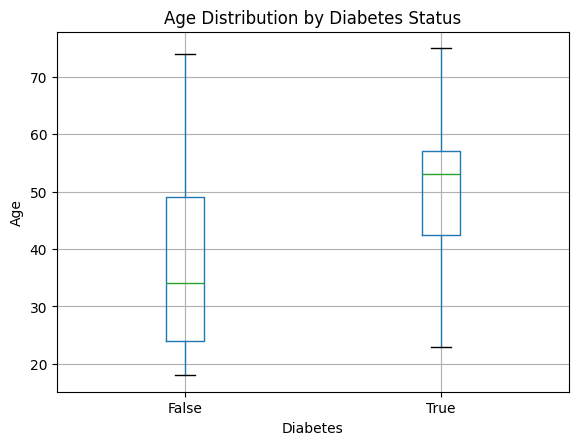

In [11]:
plt.figure()

df.boxplot(column="age", by="diabetes")

plt.title("Age Distribution by Diabetes Status")
plt.suptitle("")   # Removes automatic subtitle
plt.xlabel("Diabetes")
plt.ylabel("Age")

plt.show()

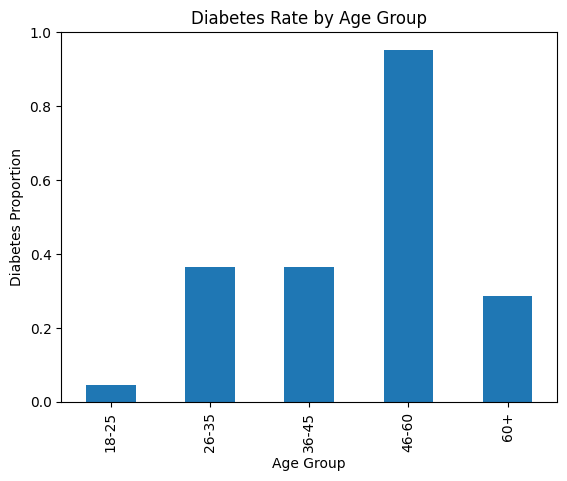

In [12]:
plt.figure()

diabetes_rate = df.groupby("age_group")["diabetes"].mean()
diabetes_rate.plot(kind="bar")

plt.title("Diabetes Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Diabetes Proportion")

plt.show()

**Interpretation**
*   p < 0.05 → Diabetes rate differs across age groups
*   p ≥ 0.05 → No significant difference




**7. Covariance and Correlation (Age vs BMI)**

In [13]:
# Covariance
cov_age_bmi = np.cov(df["age"], df["bmi"])[0,1]
cov_age_bmi

np.float64(nan)

In [14]:
# Correlation
corr_age_bmi = df["age"].corr(df["bmi"])
corr_age_bmi

np.float64(0.3249499530539976)

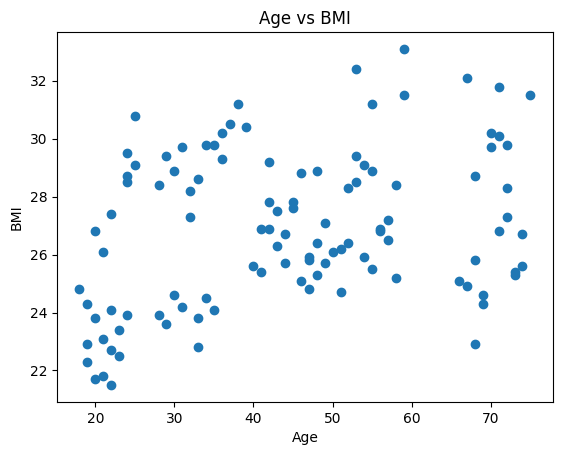

In [15]:
plt.figure()

plt.scatter(df["age"], df["bmi"])

plt.title("Age vs BMI")
plt.xlabel("Age")
plt.ylabel("BMI")

plt.show()